In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score
from sklearn.tree import plot_tree

In [25]:
data=pd.read_csv("Titanic_train.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [26]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [28]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [29]:
features=["Pclass","Sex","Fare","Embarked","Age"]
target=["Survived"]

In [30]:
imp_mean = SimpleImputer(strategy='mean')
data[["Age"]]=imp_mean.fit_transform(data[["Age"]])

In [31]:
imp=SimpleImputer(strategy="most_frequent")
data[["Embarked"]]=imp.fit_transform(data[["Embarked"]])

In [32]:
encoder=LabelEncoder()
data["Embarked"]=encoder.fit_transform(data["Embarked"])
data["Sex"]=encoder.fit_transform(data["Sex"])

In [33]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,2


In [34]:
x=data[features]
y=data[target]

In [35]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [37]:
x_train.head()

,Pclass,Sex,Fare,Embarked,Age
331,1,1,28.5000,2,45.5
733,2,1,13.0000,2,23.0
382,3,1,7.9250,2,32.0
704,3,1,7.8542,2,26.0
813,3,0,31.2750,2,6.0


In [38]:
y_train.head()

,Survived
331,0
733,0
382,0
704,0
813,0


In [40]:
model=DecisionTreeClassifier()
model.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [41]:
y_pred=model.predict(x_test)

In [46]:
print("accuracy socre:",accuracy_score(y_test,y_pred))
print("precision socre:",precision_score(y_test,y_pred))

accuracy socre: 0.770949720670391
precision socre: 0.72


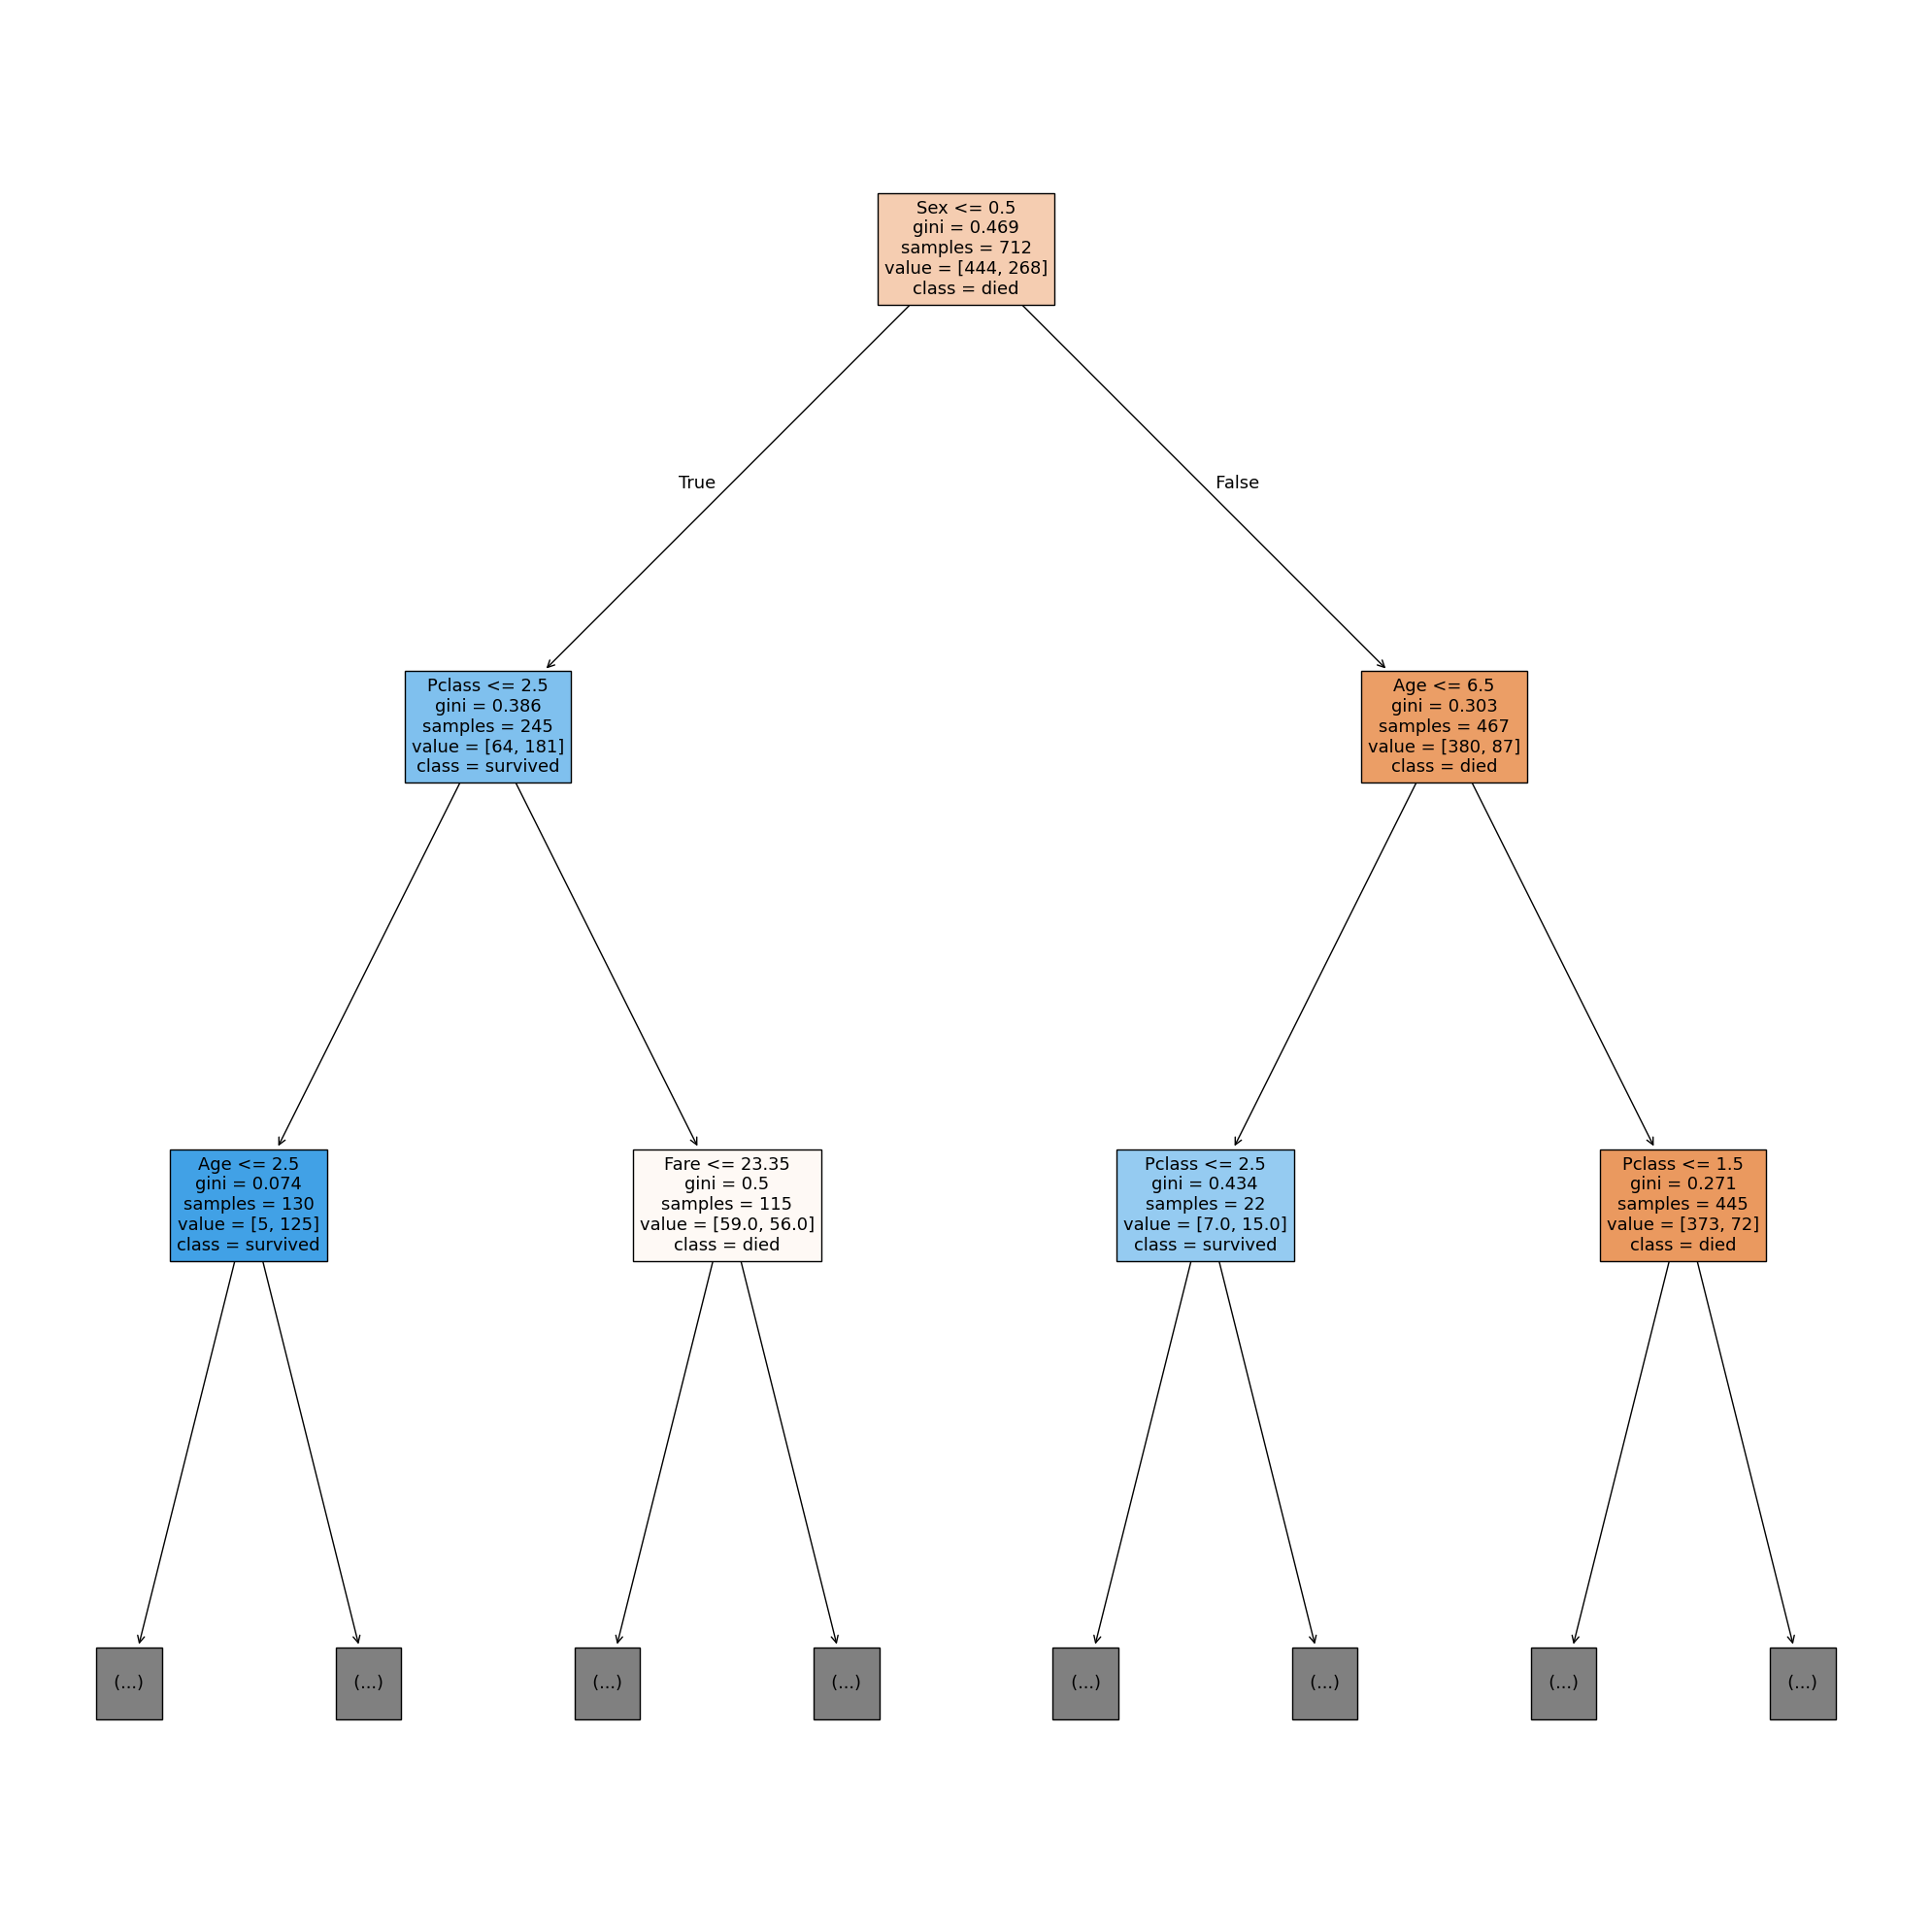

In [59]:
plt.figure(figsize=(20,20))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=["died","survived"],
    filled=True,
    max_depth=2
)
plt.tight_layout()
plt.show()

## decision tree with prepruning

for depth: 2 accuracy=0.7653631284916201
for depth: 3 accuracy=0.7988826815642458
for depth: 4 accuracy=0.7988826815642458
for depth: 5 accuracy=0.7988826815642458
for depth: 6 accuracy=0.7988826815642458
for depth: 7 accuracy=0.7988826815642458


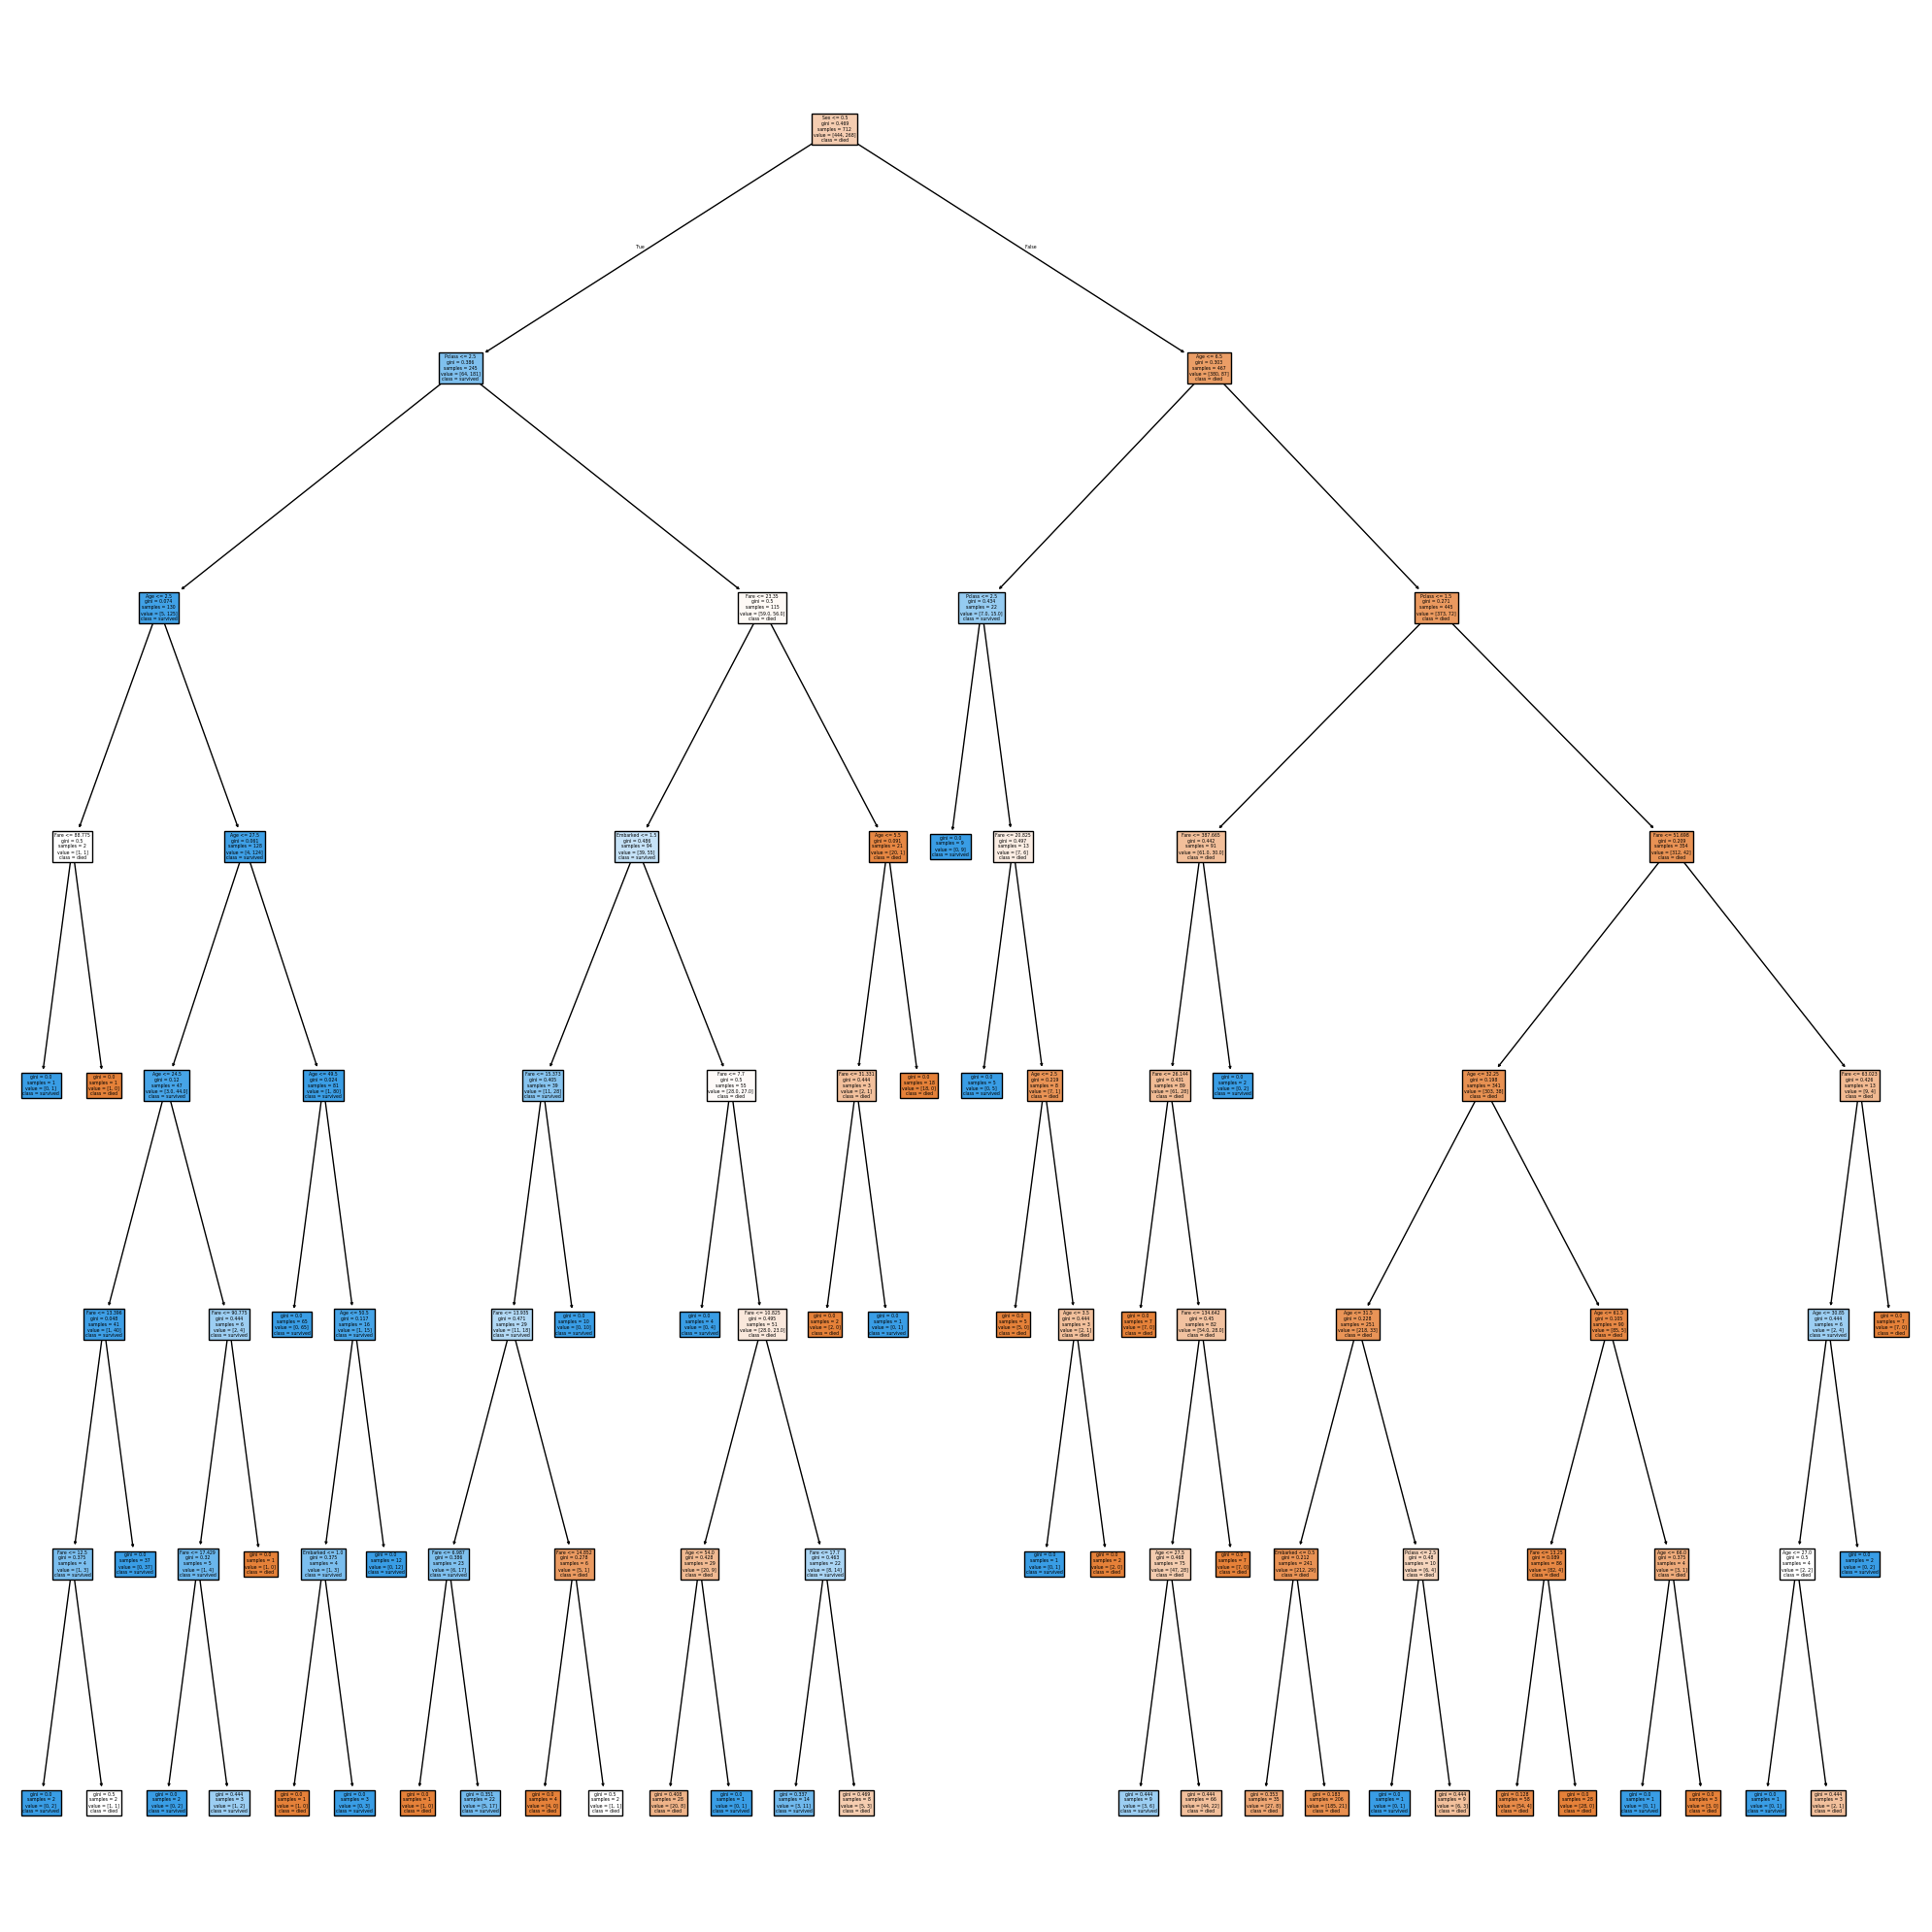

for depth: 8 accuracy=0.7877094972067039
for depth: 9 accuracy=0.7821229050279329
for depth: 10 accuracy=0.7988826815642458
for depth: 11 accuracy=0.8044692737430168
for depth: 12 accuracy=0.7988826815642458
for depth: 13 accuracy=0.7877094972067039


In [70]:
max_depth=[2,3,4,5,6,7,8,9,10,11,12,13]
for depth in max_depth:
    model=DecisionTreeClassifier(max_depth=depth)
    model.fit(x_train,y_train)
    acc=model.score(x_test,y_test)
    print(f"for depth: {depth} accuracy={acc}")

    if(depth==7):
        plt.figure(figsize=(20,20))
        plot_tree(
            model,
            feature_names=x.columns,
            class_names=["died","survived"],
            filled=True,
        )
        plt.tight_layout()
        plt.show()

for split: 5 accuracy=0.8268156424581006
for split: 7 accuracy=0.8268156424581006


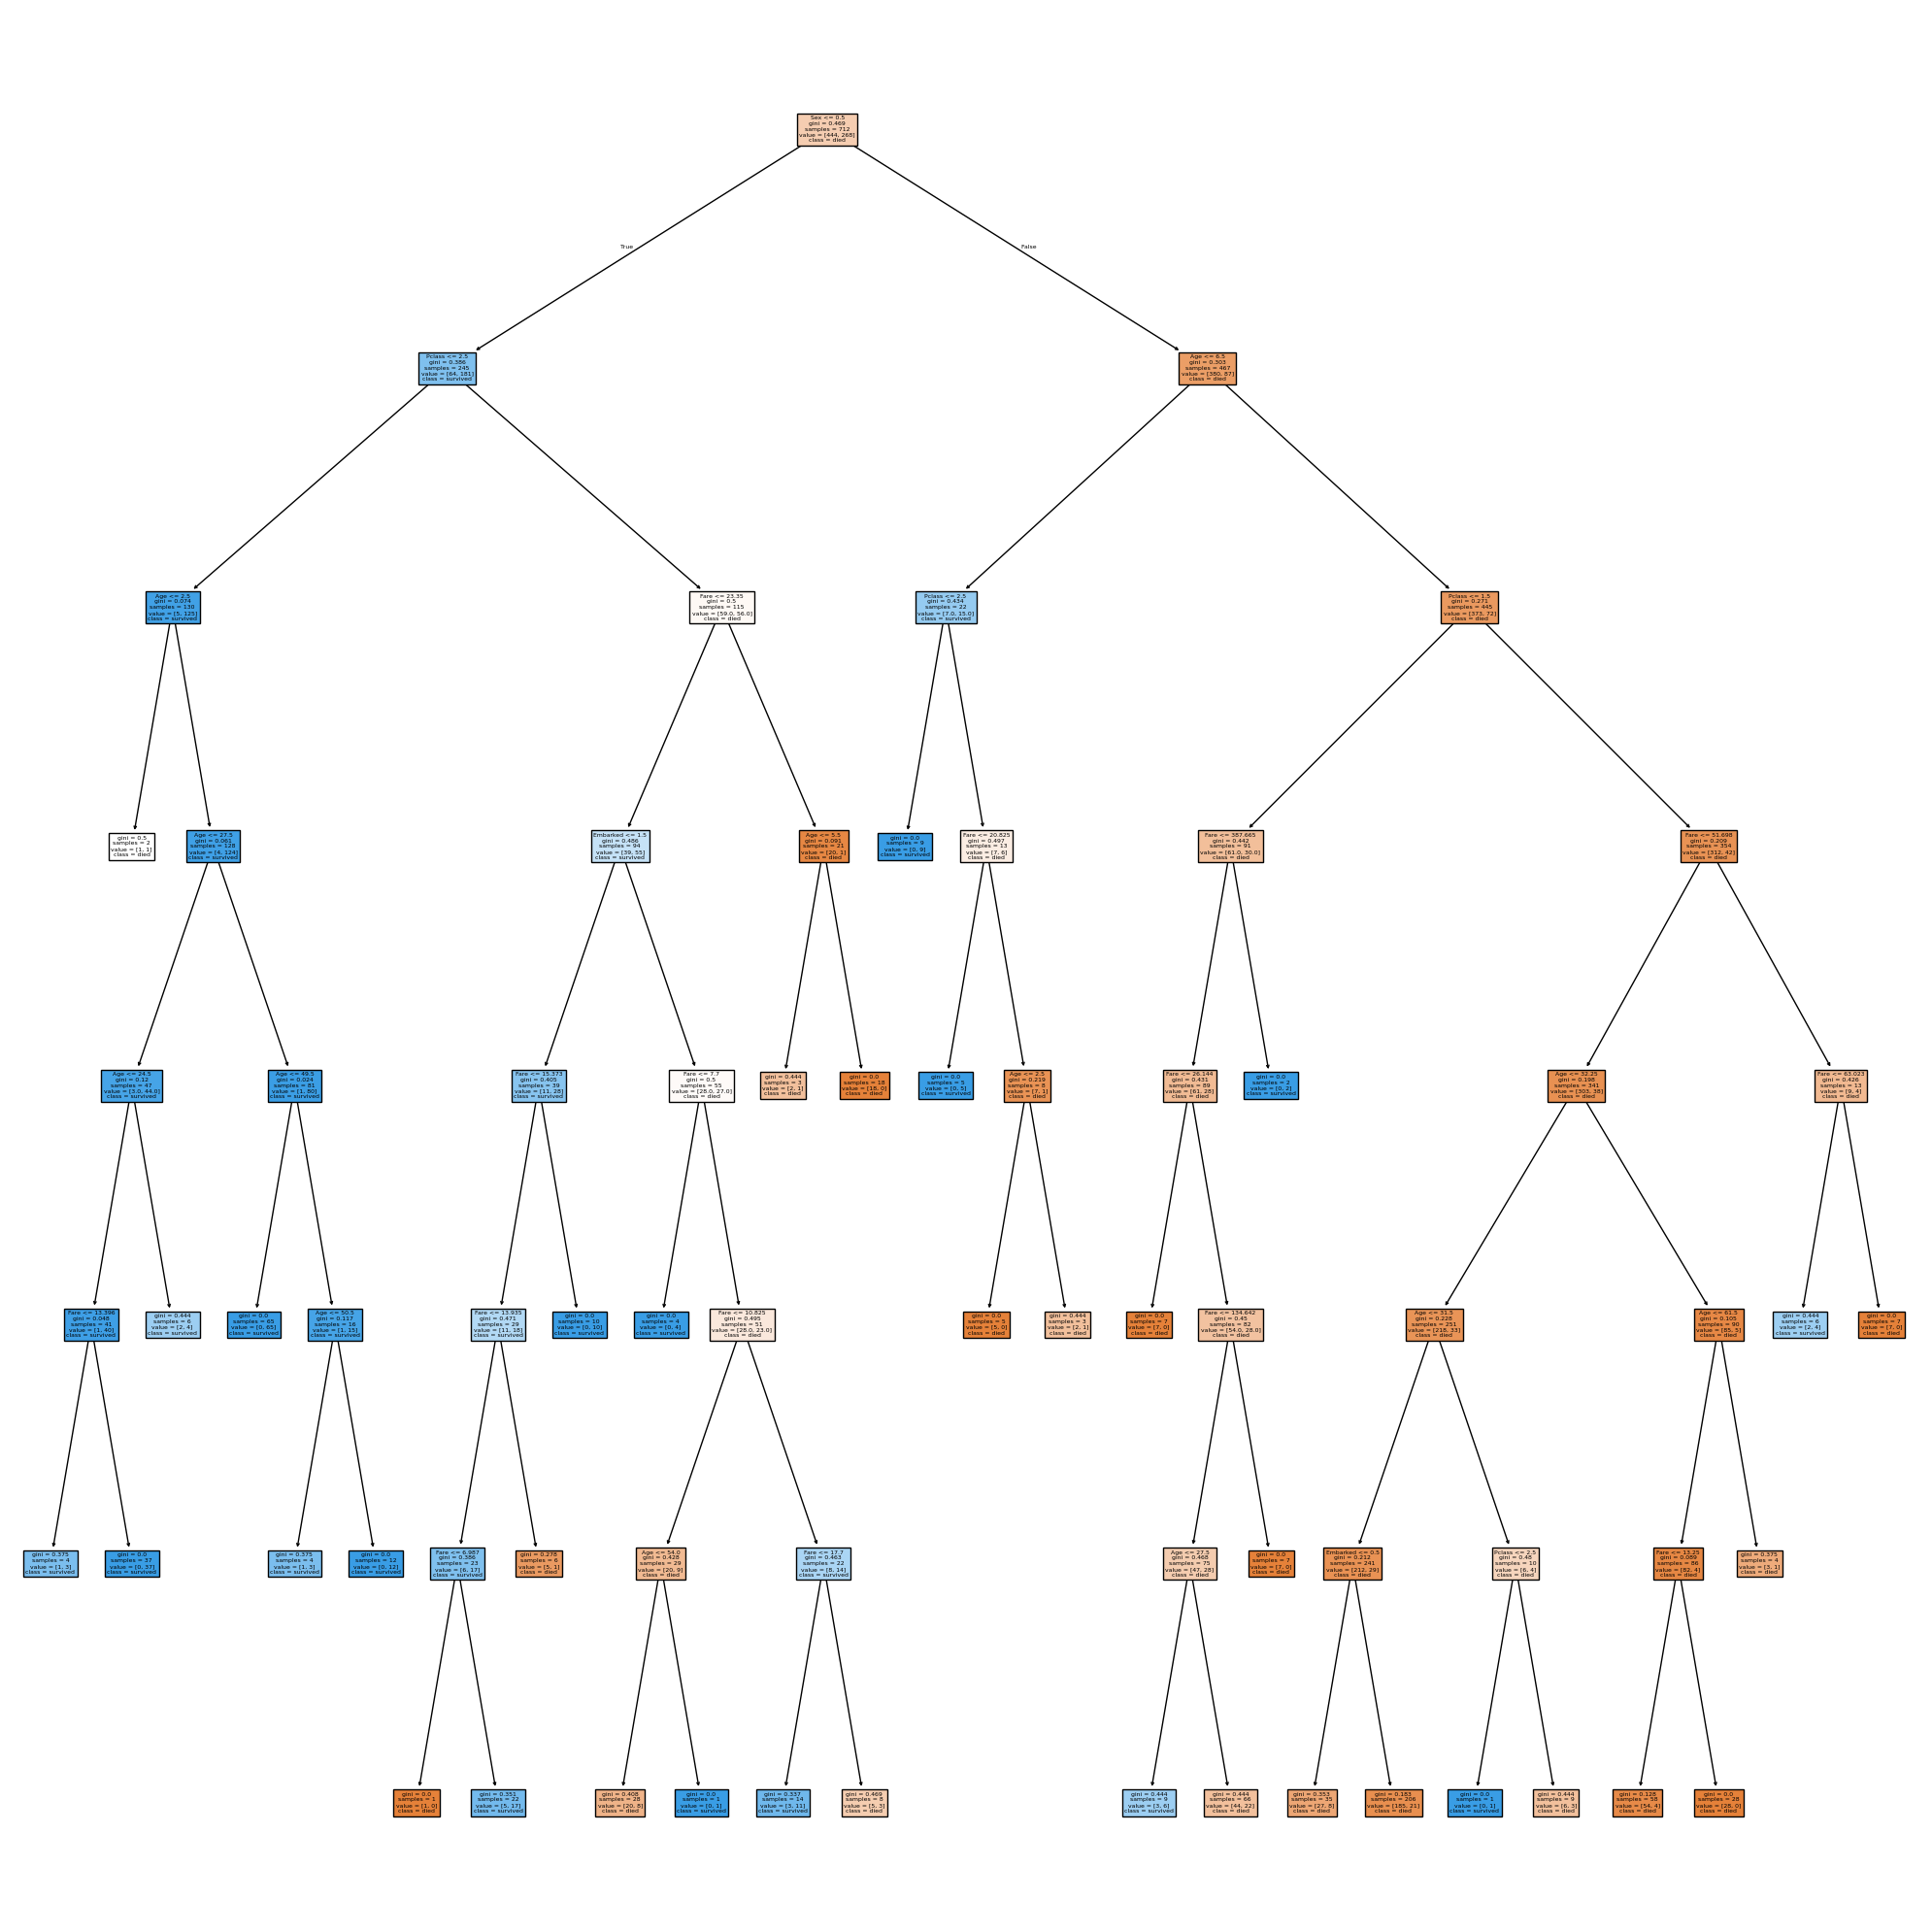

for split: 9 accuracy=0.8268156424581006
for split: 10 accuracy=0.8324022346368715
for split: 15 accuracy=0.8268156424581006
for split: 20 accuracy=0.8268156424581006
for split: 25 accuracy=0.8100558659217877
for split: 30 accuracy=0.7988826815642458
for split: 35 accuracy=0.7988826815642458


In [71]:
max_split=[5,7,9,10,15,20,25,30,35]
for split in max_split:
    model=DecisionTreeClassifier(max_depth=7,min_samples_split=split)
    model.fit(x_train,y_train)
    acc=model.score(x_test,y_test)
    print(f"for split: {split} accuracy={acc}")

    if(split==7):
        plt.figure(figsize=(20,20))
        plot_tree(
            model,
            feature_names=x.columns,
            class_names=["died","survived"],
            filled=True,
        )
        plt.tight_layout()
        plt.show()

## decision tree with post pruning

In [72]:
full_tree=DecisionTreeClassifier()
full_tree.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [73]:
path=full_tree.cost_complexity_pruning_path(x_train,y_train)
ccp_alphas=path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 3.12109863e-05 6.68806849e-05
 8.91742465e-05 1.63857678e-04 2.00642055e-04 2.34082397e-04
 2.34082397e-04 2.34082397e-04 3.51123596e-04 4.68164794e-04
 4.68164794e-04 4.68164794e-04 4.68164794e-04 5.35045479e-04
 5.61797753e-04 6.24219725e-04 6.24219725e-04 6.67991230e-04
 7.02247191e-04 8.19288390e-04 8.19288390e-04 8.42696629e-04
 8.42696629e-04 8.94231048e-04 9.24769963e-04 9.36329588e-04
 9.36329588e-04 9.36329588e-04 1.01064146e-03 1.02996255e-03
 1.07400895e-03 1.07953294e-03 1.08038029e-03 1.11865144e-03
 1.12359551e-03 1.12359551e-03 1.17041199e-03 1.17041199e-03
 1.18841832e-03 1.22566125e-03 1.22893258e-03 1.22893258e-03
 1.24843945e-03 1.27565833e-03 1.30996111e-03 1.33761370e-03
 1.33761370e-03 1.37044603e-03 1.46301498e-03 1.51229549e-03
 1.56076895e-03 1.56737310e-03 1.60434338e-03 1.64211936e-03
 1.66892062e-03 1.86751451e-03 2.10674157e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [74]:
tree=[]
for alpha in ccp_alphas:
    model=DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(x_train,y_train)
    
    tree.append((model,alpha))
    

In [77]:
best_acc=0
best_model=0
for model,alpha in tree:
    acc=model.score(x_test,y_test)
    if (acc>best_acc):
        best_acc=acc
        best_alpha=alpha

In [78]:
print(best_alpha)
print(best_acc)

0.0018675145079639476
0.8379888268156425


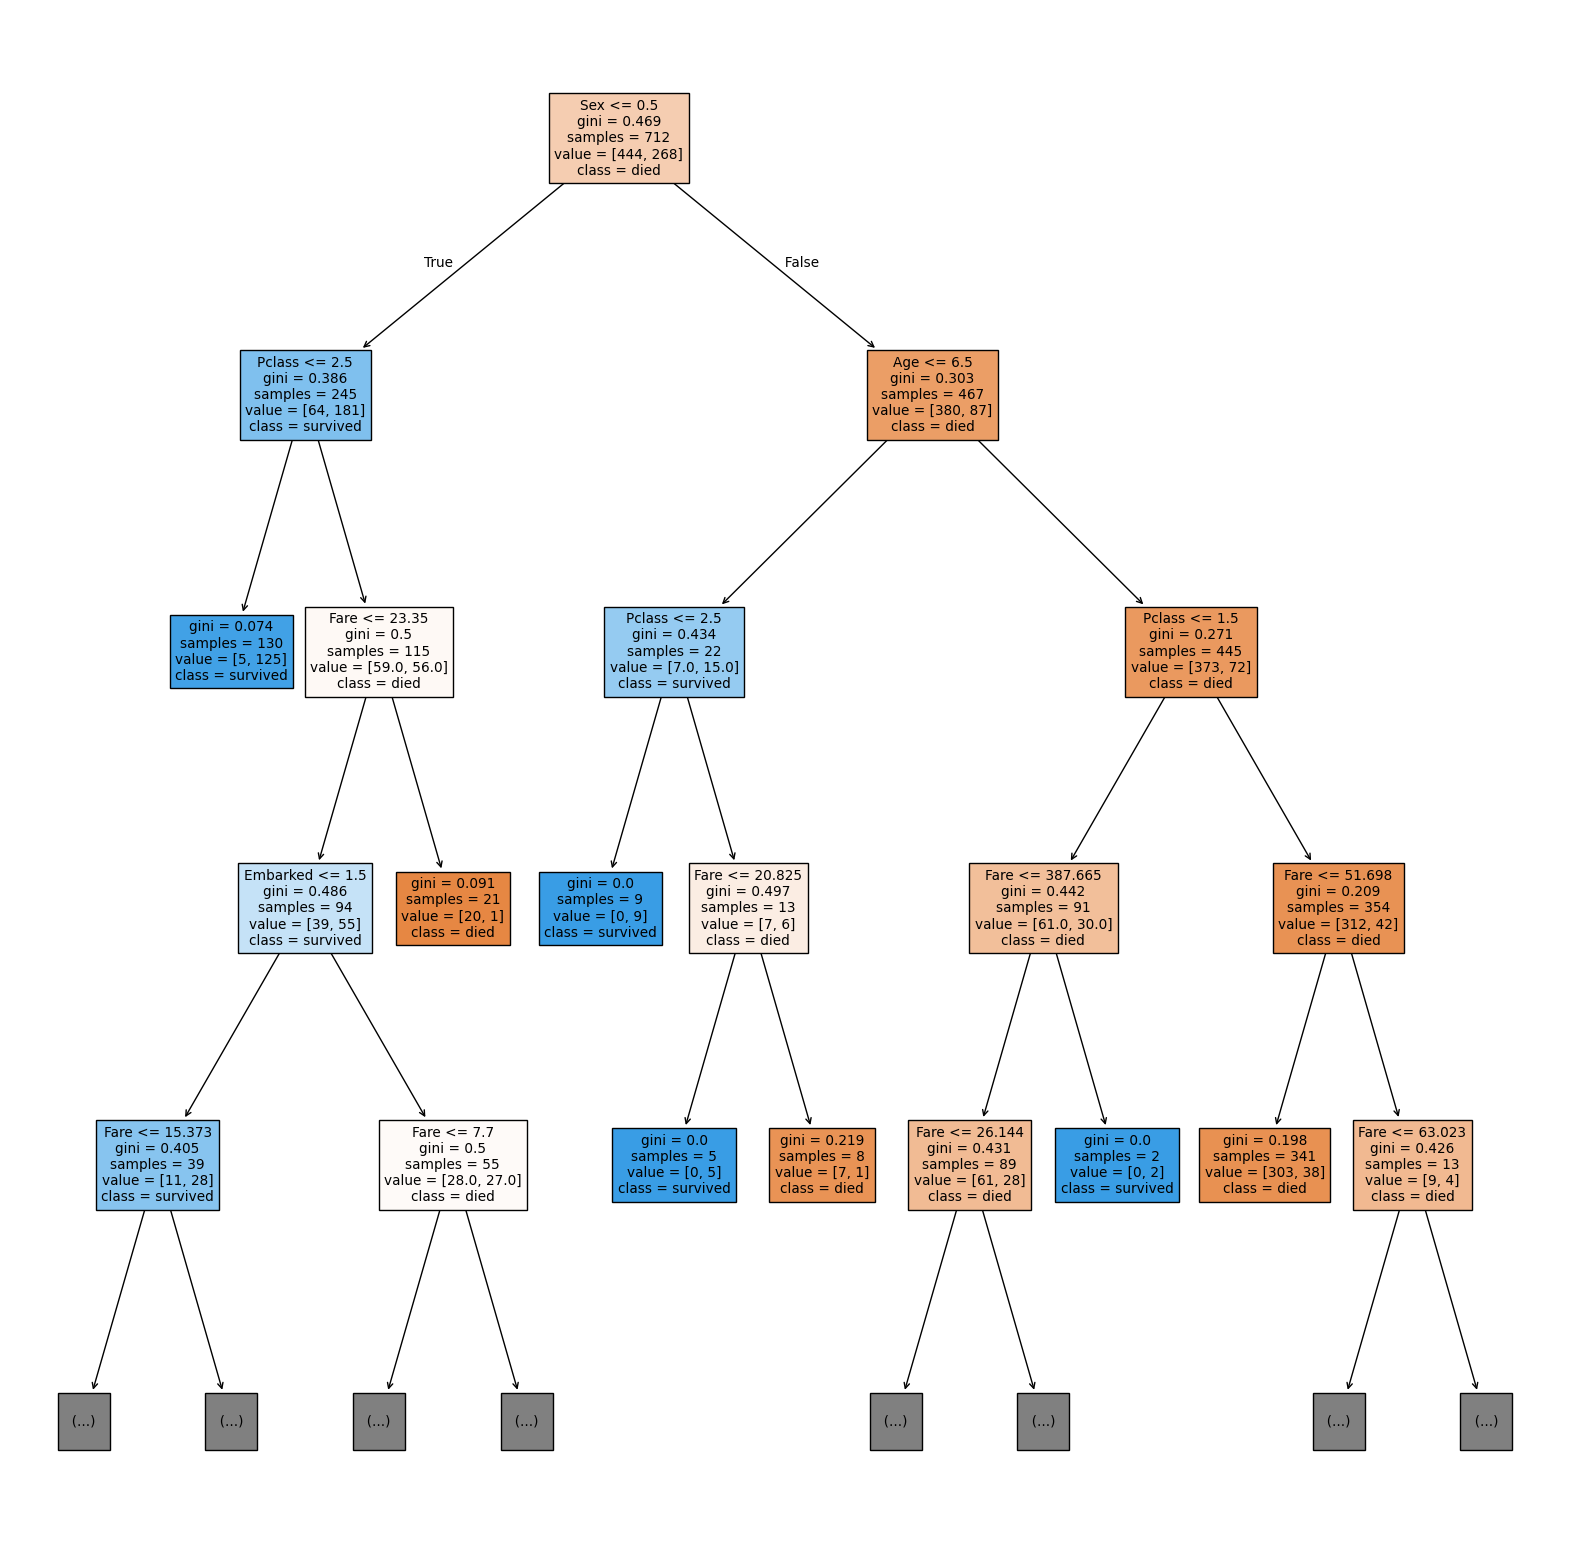

0.8379888268156425


In [94]:
best_model=DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model = DecisionTreeClassifier(random_state=42,ccp_alpha=best_alpha)
best_model.fit(x_train, y_train)

plt.figure(figsize=(20,20))
plot_tree( best_model, feature_names=x.columns,class_names=["died","survived"],filled=True,max_depth=4)
plt.show()
acc = best_model.score(x_test, y_test)

print(acc)